In [3]:
from datamodel import TradingState, Listing, OrderDepth, Observation, Symbol, Trade, Position, Order
from backtester import Backtester
from typing import Dict, List
from trader import Trader
import matplotlib.pyplot as plt
from visualizer import BacktestingResult
import numpy as np
import json

In [4]:
from data_parser import clean_df, get_group_prices
from research_tools import get_options_df, implied_vol_bisection
import pandas as pd
import matplotlib.pyplot as plt

prices_files = []
trades_files = []
round = 3
for i in range(0, 3):
    prices_files.append("./data/round_3_data/prices_round_"+str(round)+"_day_"+str(i)+".csv")
    trades_files.append("./data/round_3_data/trades_round_"+str(round)+"_day_"+str(i)+".csv")
df=get_group_prices(prices_files)

In [3]:
df.head(10)

,index,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,0,VEV_5400,22,25,0,0,0,0,24,25,0,0,0,0,23.0,0.0
1,1,0,0,VEV_6500,0,16,0,0,0,0,1,16,0,0,0,0,0.5,0.0
2,2,0,0,VEV_5500,8,25,0,0,0,0,9,25,0,0,0,0,8.5,0.0
3,3,0,0,VEV_5200,100,19,0,0,0,0,103,6,104,13,0,0,101.5,0.0
4,4,0,0,VEV_5300,52,6,51,19,0,0,54,25,0,0,0,0,53.0,0.0
5,5,0,0,VELVETFRUIT_EXTRACT,5247,67,0,0,0,0,5253,67,0,0,0,0,5250.0,0.0
6,6,0,0,VEV_4500,742,6,740,13,0,0,758,6,760,13,0,0,750.0,0.0
7,7,0,0,HYDROGEL_PACK,9992,15,9990,30,0,0,10008,15,10010,30,0,0,10000.0,0.0
8,8,0,0,VEV_5000,254,19,0,0,0,0,260,6,261,13,0,0,257.0,0.0
9,9,0,0,VEV_4000,1240,7,1237,24,0,0,1260,7,1263,24,0,0,1250.0,0.0


In [5]:
def ultra_slow_mean(prices, alpha=0.01):
    trend = None
    out = []

    for p in prices:
        if trend is None:
            trend = p
        else:
            trend = alpha * p + (1 - alpha) * trend

        out.append(trend)

    return np.array(out)
def kalman_trend_mean_reverting(prices,
                               process_var=1e-6,
                               measurement_var=25.0,
                               kappa=0.05):  # mean reversion speed

    n = len(prices)

    # State: [trend, residual]
    x = np.array([prices[0], 0.0])
    P = np.eye(2)

    # Transition
    F = np.array([
        [1, 0],
        [0, (1 - kappa)]   # residual mean reverts
    ])

    # Observation: price = trend + residual
    H = np.array([[1, 1]])

    Q = np.array([
        [process_var, 0],
        [0, process_var]
    ])

    R = np.array([[measurement_var]])

    trend = []
    residuals = []

    for z in prices:
        # Predict
        x = F @ x
        P = F @ P @ F.T + Q

        # Update
        y = np.array([z]) - H @ x
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)

        x = x + (K @ y).flatten()
        P = (np.eye(2) - K @ H) @ P

        trend.append(x[0])
        residuals.append(x[1])

    return np.array(trend), np.array(residuals)
def decaying_midrange(prices, alpha=0.001):
    max_est = None
    min_est = None
    out = []

    for p in prices:
        if max_est is None:
            max_est = p
            min_est = p
        else:
            # decay previous extremes toward current price
            max_est = max(p, (1 - alpha) * max_est + alpha * p)
            min_est = min(p, (1 - alpha) * min_est + alpha * p)

        mid = (max_est + min_est) / 2
        out.append(mid)

    return np.array(out)

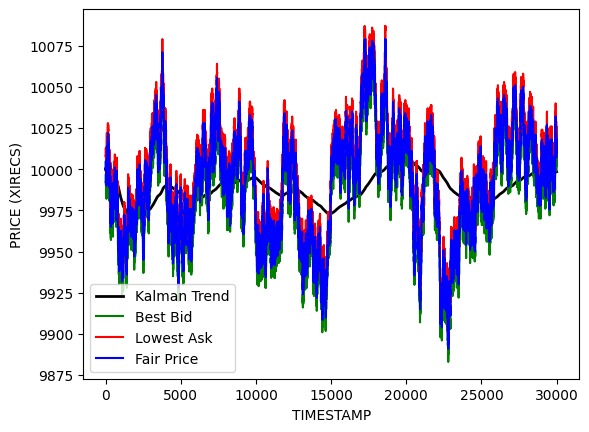

In [6]:
#hydro RESEARCH

hydro_bid_price = df.loc[df['product']=="HYDROGEL_PACK"]["bid_price_1"].to_numpy()
hydro_ask_price = df.loc[df['product']=="HYDROGEL_PACK"]["ask_price_1"].to_numpy()
hydro_mid_price = df.loc[df['product']=="HYDROGEL_PACK"]["mid_price"].to_numpy().astype(float)
trend_line = ultra_slow_mean(hydro_mid_price)
midrange_line = decaying_midrange(hydro_mid_price, alpha=0.0001)
kalman_trend, kalman_resid = kalman_trend_mean_reverting(hydro_mid_price)

plt.plot(kalman_trend, color="black", linewidth=2, label="Kalman Trend")

plt.plot([i for i in range(len(hydro_bid_price))], hydro_bid_price, color="green", label="Best Bid")
plt.plot([i for i in range(len(hydro_ask_price))], hydro_ask_price, color="red", label="Lowest Ask")
plt.plot([i for i in range(len(hydro_bid_price))], hydro_mid_price, color="blue", label="Fair Price")
#plt.plot(midrange_line, color="purple", linewidth=2, label="Decaying Midrange")

plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

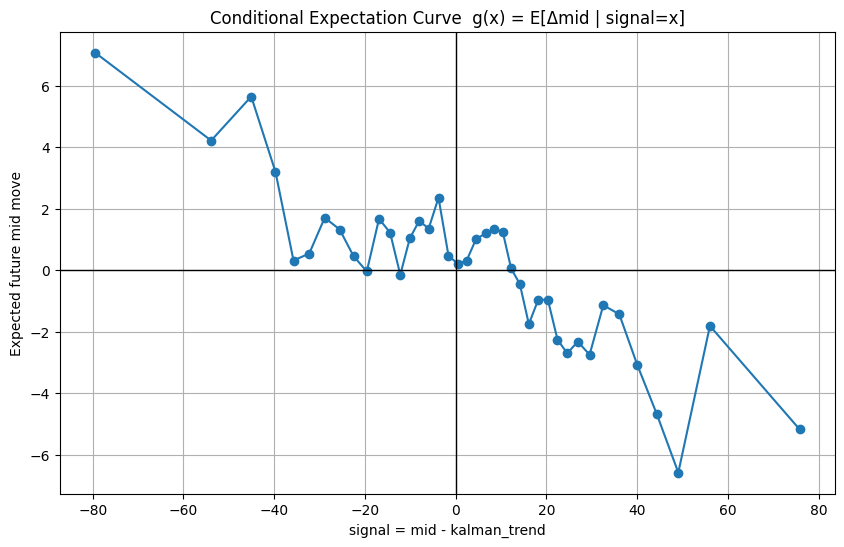

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Extract mid + kalman trend
# -----------------------------
mid = hydro_mid_price.astype(float)
kal = kalman_trend.astype(float)

# -----------------------------
# 2. Define signal
# -----------------------------
signal = mid - kal

# -----------------------------
# 3. Choose quoting horizon H
# -----------------------------
H = 50   # <-- adjust if needed

future_move = mid[H:] - mid[:-H]
signal_H = signal[:-H]

# -----------------------------
# 4. Quantile binning
# -----------------------------
nbins = 41
edges = np.quantile(signal_H, np.linspace(0, 1, nbins))
centers = 0.5 * (edges[1:] + edges[:-1])

digitized = np.digitize(signal_H, edges) - 1

# -----------------------------
# 5. Compute conditional expectation curve g(x)
# -----------------------------
g = np.array([
    future_move[digitized == i].mean() if np.any(digitized == i) else np.nan
    for i in range(nbins - 1)
])

# -----------------------------
# 6. Plot the curve
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(centers, g, marker='o')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.title("Conditional Expectation Curve  g(x) = E[Δmid | signal=x]")
plt.xlabel("signal = mid - kalman_trend")
plt.ylabel("Expected future mid move")
plt.grid(True)
plt.show()


In [135]:
hydro_ask_price.mean()

np.float64(9998.667266666667)

In [153]:
hydro_ask_price.mean() + hydro_ask_price.std()*1

np.float64(10030.634859973987)

In [154]:
hydro_bid_price.mean() - hydro_bid_price.std()*1

np.float64(9951.028144851201)

In [89]:
# Check hydrogel EMA reverting behavior
def ema_mp(mid_prices, alpha):
    mid_prices = np.array(mid_prices, dtype=float)
    ema = np.zeros_like(mid_prices)

    # Initialize EMA with first value
    ema[0] = mid_prices[0]

    # Compute EMA
    for i in range(1, len(mid_prices)):
        ema[i] = alpha * mid_prices[i] + (1 - alpha) * ema[i-1]

    return ema - mid_prices

def ema(mid_prices, alpha):
    mid_prices = np.array(mid_prices, dtype=float)
    ema = np.zeros_like(mid_prices)

    # Initialize EMA with first value
    ema[0] = mid_prices[0]

    # Compute EMA
    for i in range(1, len(mid_prices)):
        ema[i] = alpha * mid_prices[i] + (1 - alpha) * ema[i-1]
    return ema

def ema_window(x, alpha, window):
    x = np.asarray(x, float)

    # exponential weights (oldest → newest)
    w = alpha * (1 - alpha) ** np.arange(window)
    w = w[::-1]
    w /= w.sum()  # normalize to sum to 1

    # convolution gives right‑aligned windowed EMA
    out = np.convolve(x, w, mode='full')
    return out[window-1:]


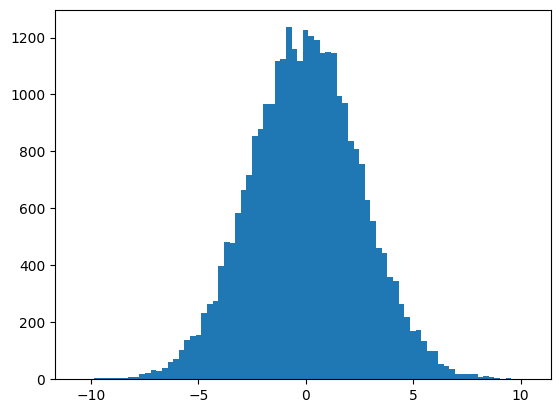

In [90]:
plt.hist(ema_mp(hydro_mid_price,0.2), bins = 80)
plt.show()

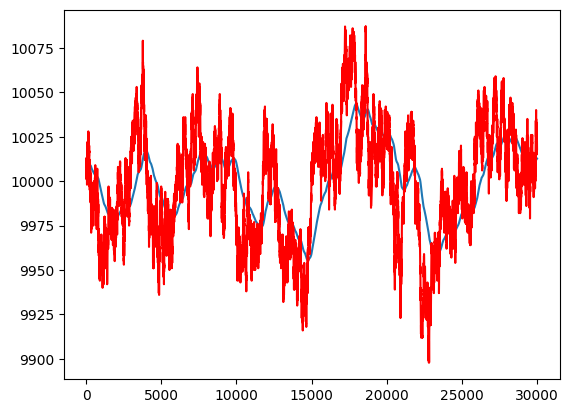

In [91]:
plt.plot(ema(hydro_ask_price, 0.001))
plt.plot(hydro_ask_price, color="red")
plt.show()

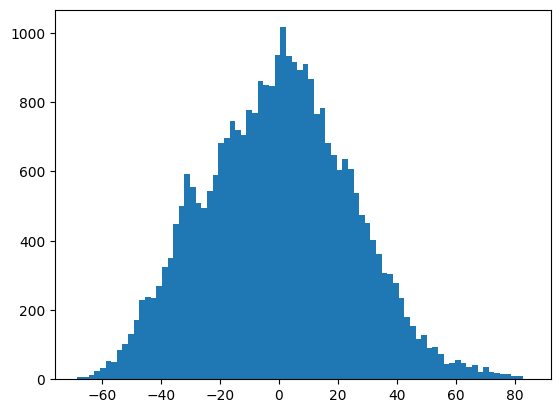

In [92]:
plt.hist(ema(hydro_ask_price, 0.001)-hydro_ask_price, bins = 80)
plt.show()

In [93]:
mid = np.array(hydro_ask_price)
signal = ema_mp(hydro_ask_price, 0.01)
H = 10


dmid = mid[H:] - mid[:-H]
sig  = signal[:-H]

nbins = 50

edges = np.quantile(sig, np.linspace(0, 1, nbins + 1))

idx = np.digitize(sig, edges) - 1

g = np.zeros(nbins)
for b in range(nbins):
    mask = idx == b
    g[b] = dmid[mask].mean() if np.any(mask) else np.nan

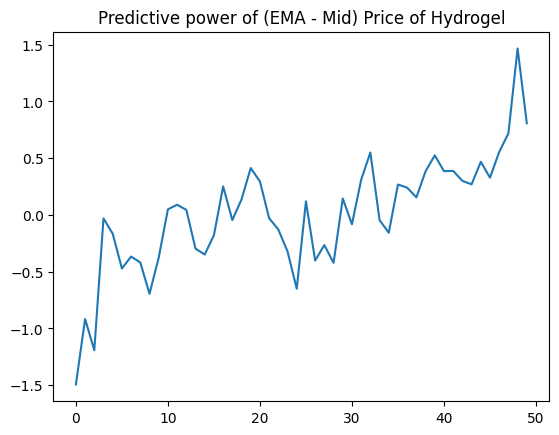

In [94]:
plt.plot(g)
plt.title("Predictive power of (EMA - Mid) Price of Hydrogel")
plt.show()

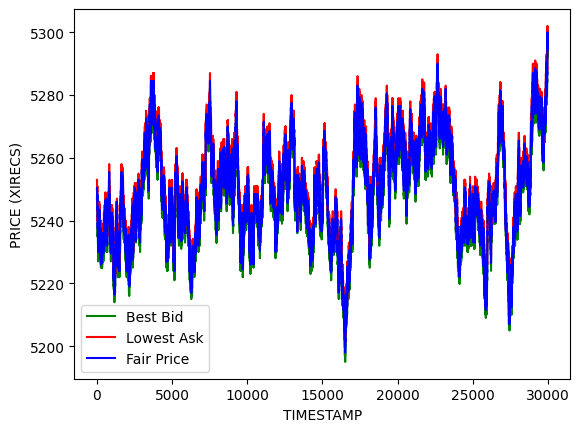

In [104]:
#extract RESEARCH

extract_bid_price = df.loc[df['product']=="VELVETFRUIT_EXTRACT"]["bid_price_1"].to_numpy()
extract_ask_price = df.loc[df['product']=="VELVETFRUIT_EXTRACT"]["ask_price_1"].to_numpy()
extract_mid_price = df.loc[df['product']=="VELVETFRUIT_EXTRACT"]["mid_price"].to_numpy().astype(float)

plt.plot([i for i in range(len(hydro_bid_price))], extract_bid_price, color="green", label="Best Bid")
plt.plot([i for i in range(len(hydro_ask_price))], extract_ask_price, color="red", label="Lowest Ask")
plt.plot([i for i in range(len(hydro_bid_price))], extract_mid_price, color="blue", label="Fair Price")
plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

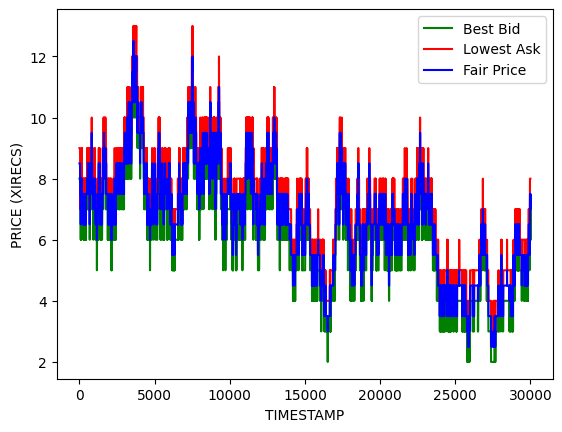

In [188]:
contract_n="VEV_5500"

vev_bid_price = df.loc[df['product']==contract_n]["bid_price_1"].to_numpy()
vev_ask_price = df.loc[df['product']==contract_n]["ask_price_1"].to_numpy()
vev_mid_price = df.loc[df['product']==contract_n]["mid_price"].to_numpy().astype(float)

plt.plot([i for i in range(len(vev_bid_price))], vev_bid_price, color="green", label="Best Bid")
plt.plot([i for i in range(len(vev_bid_price))], vev_ask_price, color="red", label="Lowest Ask")
plt.plot([i for i in range(len(vev_bid_price))], vev_mid_price, color="blue", label="Fair Price")
plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

In [5]:
vouchers = ['VEV_4000', 'VEV_4500',
            'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500',
            'VEV_6000', 'VEV_6500']
odf=get_options_df(clean_df(pd.read_csv("./data/round_3_data/prices_round_3_day_0.csv")), 7, "VELVETFRUIT_EXTRACT", vouchers)

In [6]:
moneyness=np.log((odf["strike"].to_numpy()/odf["spot_price"].to_numpy())) / np.sqrt(odf["time_to_expiry"])
iv_array = odf["implied_volatility"].to_numpy()

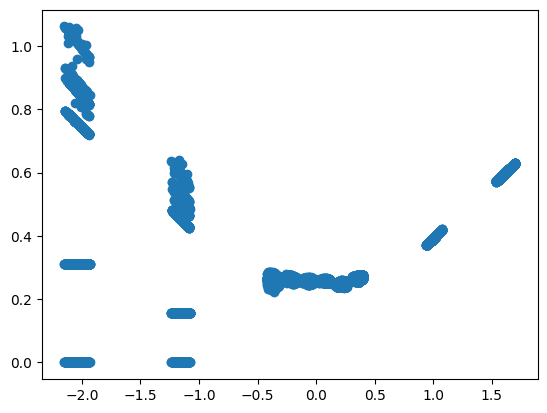

In [7]:
import matplotlib.pyplot as plt
plt.scatter(moneyness, iv_array)

In [8]:
# Take outliers
def filter_outliers(moneyness_arr, implied_vols):
    m_result, vol_result = [], []
    for i in range(len(implied_vols)):
        if implied_vols[i] > 0.1:
            m_result.append(moneyness_arr[i])
            vol_result.append(implied_vols[i])
    return (np.array(m_result), np.array(vol_result))

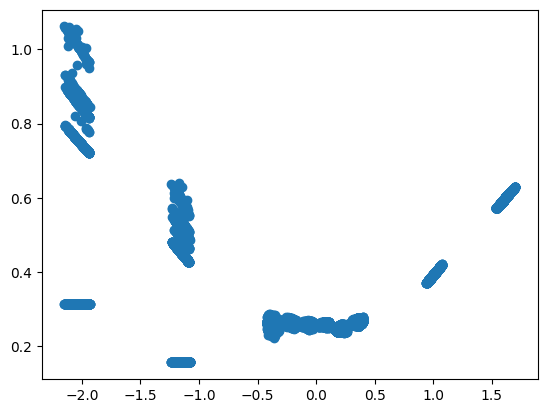

In [9]:
import matplotlib.pyplot as plt
new_moneyness, new_iv = filter_outliers(moneyness, iv_array)
plt.scatter(new_moneyness, new_iv)

In [10]:
# Fitting the smoooth IV curve

coeffs = np.polyfit(new_moneyness, new_iv, 2)
c=coeffs[2]
b=coeffs[1]
a=coeffs[0]
model = np.poly1d(coeffs)

In [11]:
# Print Parameters
print("a: " + str(a))
print("b: " + str(b))
print("c: " + str(c))

a: 0.07173831614727838
b: 0.08183947405017007
c: 0.255766877900211


In [ ]:
# sample func for model
def calc_smooth_iv(calc_moneyness):
    a=0.1368574586854027
    b=-0.01235417838031299
    c=0.25334835546239415
    return a * calc_moneyness**2 + b * calc_moneyness + c 

In [ ]:
calc_smooth_iv(-0.2)

0.24457164395285558

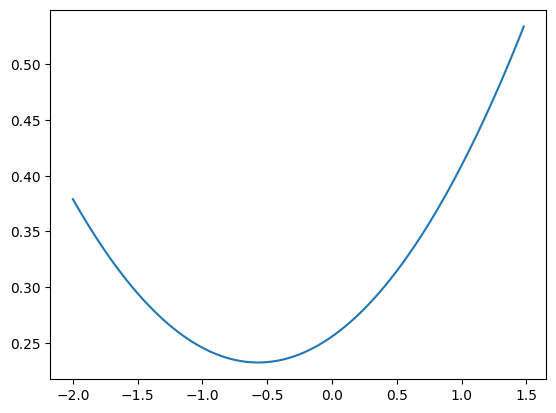

In [12]:
res = []
x=[]
m=-2
while (m<=1.5):
    x.append(m)
    res.append(model(m))
    m+=0.02
plt.plot(x,res)

In [440]:
import json
from datamodel import OrderDepth, TradingState, Order
from typing import Dict, List
from statistics import NormalDist
import numpy as np
#glob = []

class UserTrader:
    def __init__(self):
        self.alpha = 0.1  # EMA SMOOTH
        self.ema_hydrogel = None  # EMA state
        self.vouchers = ['VEV_4000', 'VEV_4500',
            'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500',
            'VEV_6000', 'VEV_6500']
        self.strikes = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
    def calc_smooth_iv(self, calc_moneyness):
        a=0.1368574586854027
        b=-0.01235417838031299
        c=0.25334835546239415
        return a * calc_moneyness**2 + b * calc_moneyness + c 
    def get_weighted_liquidity(self, state: TradingState, symbol: str):
        weighted_bid = 0
        weighted_ask = 0

        volume_sum_bids = 0
        volume_sum_asks = 0

        for price in state.order_depths[symbol].buy_orders:
            weighted_bid += (price * state.order_depths[symbol].buy_orders[price])
            volume_sum_bids += state.order_depths[symbol].buy_orders[price]

        for price in state.order_depths[symbol].sell_orders:
            weighted_ask += (price * abs(state.order_depths[symbol].sell_orders[price]))
            volume_sum_asks += abs(state.order_depths[symbol].sell_orders[price])

        weighted_bid /= volume_sum_bids
        weighted_ask /= volume_sum_asks
        
        return (weighted_bid + weighted_ask) / 2


    def update_ema_hydrogel_ask(self, state: TradingState, mp):
        if self.ema_hydrogel_ask is None:
            self.ema_hydrogel_ask = mp
        else:
            self.ema_hydrogel_ask = self.alpha * mp + (1 - self.alpha) * self.ema_hydrogel_ask
    def update_ema_hydrogel_bid(self, state: TradingState, mp):
        if self.ema_hydrogel_bid is None:
            self.ema_hydrogel_bid = mp
        else:
            self.ema_hydrogel_bid = self.alpha * mp + (1 - self.alpha) * self.ema_hydrogel_bid

    def trade_hydrogel_pack_mean_rev(self, state: TradingState):
        symbol = "HYDROGEL_PACK"
        LIMIT = 200
        ORDER_SIZE = 20


        if len(state.order_depths[symbol].buy_orders) == 0 or len(state.order_depths[symbol].sell_orders) == 0:
            return

        best_bid = max(state.order_depths[symbol].buy_orders)
        best_ask = min(state.order_depths[symbol].sell_orders)
        mid = (best_bid + best_ask) / 2

        position = state.position.get(symbol, 0)
        alpha_hgp = 0.0001
        if "max_est_hgp" not in self.trader_state:
            self.trader_state["max_est_hgp"] = mid
            self.trader_state["min_est_hgp"] = mid
        else:
            self.trader_state["max_est_hgp"] = max(mid, (1 - alpha_hgp) * self.trader_state["max_est_hgp"] + alpha_hgp * mid)
            self.trader_state["min_est_hgp"] = min(mid, (1 - alpha_hgp) * self.trader_state["min_est_hgp"] + alpha_hgp * mid)
            
        true_fair = (self.trader_state["max_est_hgp"] + self.trader_state["min_est_hgp"]) / 2
        BUY_THRESHOLD = true_fair - 30 
        SELL_THRESHOLD = true_fair + 30

        if best_ask <= BUY_THRESHOLD:
            available = LIMIT - position
            if available > 0:
                qty = min(ORDER_SIZE, available)
                self.result[symbol].append(Order(symbol, best_ask, qty))

        if best_bid >= SELL_THRESHOLD:
            available = LIMIT + position
            if available > 0:
                qty = min(ORDER_SIZE, available)
                self.result[symbol].append(Order(symbol, best_bid, -qty))
    
    def trade_velvetfruit_mean_rev(self, state: TradingState):
        symbol_name: str = "VELVETFRUIT_EXTRACT"
        LIMIT = 200
        BUY_THRESHOLD = 5220
        SELL_THRESHOLD = 5260
        ORDER_SIZE = 20  # size per order, tune as needed

        position = state.position.get(symbol_name, 0)

        if len(state.order_depths[symbol_name].buy_orders) == 0 or len(state.order_depths[symbol_name].sell_orders) == 0:
            return

        best_bid = max(state.order_depths[symbol_name].buy_orders)
        best_ask = min(state.order_depths[symbol_name].sell_orders)

        # --- BUY SIGNAL: best ask is at or below buy threshold ---
        if best_ask <= BUY_THRESHOLD:
            # How much room do we have before hitting the long limit?
            available_to_buy = LIMIT - position
            if available_to_buy > 0:
                qty = min(ORDER_SIZE, available_to_buy)
                self.result[symbol_name].append(
                    Order(symbol_name, best_ask, qty)  # aggressive: hit the ask
                )

        # --- SELL SIGNAL: best bid is at or above sell threshold ---
        if best_bid >= SELL_THRESHOLD:
            # How much room do we have before hitting the short limit?
            available_to_sell = LIMIT + position  # position can be negative
            if available_to_sell > 0:
                qty = min(ORDER_SIZE, available_to_sell)
                self.result[symbol_name].append(
                    Order(symbol_name, best_bid, -qty)  # aggressive: hit the bid
                )
    def norm_cdf_fast(self,x):
        k = 1.0 / (1.0 + 0.2316419 * abs(x))
        poly = k * (0.319381530 + k * (-0.356563782 +
        k * (1.781477937 + k * (-1.821255978 + 1.330274429 * k))))
        w = 1.0 - (1.0 / np.sqrt(2*np.pi)) * np.exp(-0.5 * x * x) * poly
        return w if x >= 0 else 1 - w

    def black_scholes_call(self,spot, strike, t, vol, r=0.0):
        sqrt_t = np.sqrt(t)
        d1 = (np.log(spot/strike) + (r + 0.5*vol*vol)*t) / (vol*sqrt_t)
        d2 = d1 - vol*sqrt_t
        return spot * NormalDist().cdf(d1)- strike * np.exp(-r*t) * NormalDist().cdf(d2)
    
    def trade_vouchers(self, state:TradingState):
        max_expiry = (7*1_000_000)
        underlying_asset = "VELVETFRUIT_EXTRACT"
        arr=[]
        for i in range(len(self.vouchers)):
            strike_i = self.strikes[i]
            voucher_i = self.vouchers[i]
            # Check for liquidity
            if strike_i != 5000:
                continue
            if len(state.order_depths[voucher_i].buy_orders) == 0 or len(state.order_depths[voucher_i].sell_orders) == 0:
                arr.append(0)
                continue
            
            voucher_bb = max(state.order_depths[voucher_i].buy_orders)
            voucher_ba = min(state.order_depths[voucher_i].sell_orders)
            spread_cost = int((voucher_ba - voucher_bb) / 2)
            market_price = int((voucher_bb + voucher_ba) / 2)

            time_to_expiry = (max_expiry - state.timestamp) / 365e6

            best_bid = max(state.order_depths[underlying_asset].buy_orders)
            best_ask = min(state.order_depths[underlying_asset].sell_orders)
            underlying_price = int((best_bid + best_ask) / 2)
            m_t = np.log(underlying_price / strike_i) / np.sqrt(time_to_expiry)
            est_iv = self.calc_smooth_iv(m_t)
            
            if voucher_i not in self.trader_state["iv_ema"]:
                self.trader_state["iv_ema"][voucher_i] = est_iv
            else:
                self.trader_state["iv_ema"][voucher_i] = self.alpha * est_iv + (1 - self.alpha) * self.trader_state["iv_ema"][voucher_i]
            est_price = self.black_scholes_call(underlying_price, strike_i, time_to_expiry, self.trader_state["iv_ema"][voucher_i])
            price_error = est_price-market_price
            position = state.position.get(voucher_i, 0)
            LIMIT = 50
            
            if price_error >= 2 and abs(price_error) > spread_cost and position < LIMIT:
                qty = min(10, LIMIT - position)
                self.result[voucher_i].append(Order(voucher_i, voucher_ba, qty))
            elif price_error <= -1.5 and abs(price_error) > spread_cost and position > -LIMIT:
                qty = min(10, LIMIT + position)
                self.result[voucher_i].append(Order(voucher_i, voucher_bb, -qty))
            

            #arr.append(price_error)
        #glob.append(arr)

    
    def reset(self):
        self.result = {}
        self.result["HYDROGEL_PACK"] = []
        self.result["VELVETFRUIT_EXTRACT"] = []
        for voucher_n in self.vouchers:
            self.result[voucher_n]=[]
        
        
    def run(self, state: TradingState):
        self.reset()
        
        if state.traderData and state.traderData != "":
            self.trader_state = json.loads(state.traderData)
        else:
            self.trader_state = {"iv_ema": {}}
        #self.trade_vouchers(state)
        #self.trade_hydrogel_pack_mm(state)
        self.trade_hydrogel_pack_mean_rev(state)
        return self.result, 0, json.dumps(self.trader_state)

In [15]:
backtesting_engine = Backtester(prices_files, trades_files)

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("", 0)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Project

In [264]:

def get_col(mat, col_idx):
    return mat[:, col_idx].copy()

In [ ]:
sample_trader = UserTrader()
#backtesting_engine.custom_shifter["TOMATOES"]=1.5
backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=False, enable_market_trades=True)

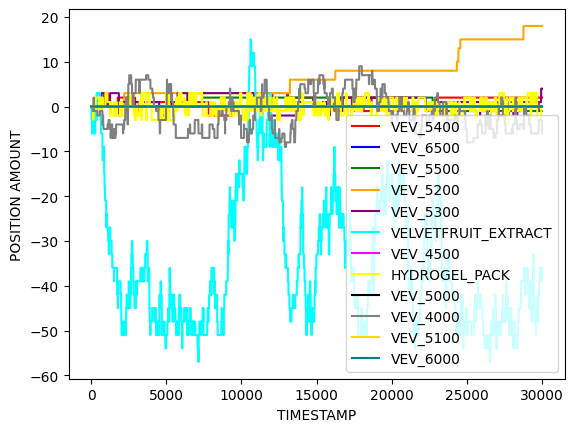

In [451]:
backtesting_result.graph_inventory()

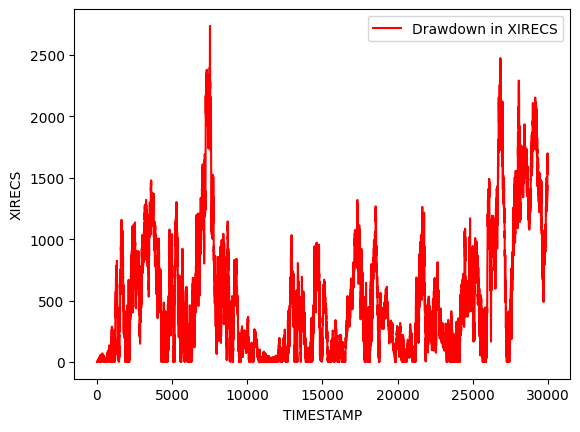

In [452]:
backtesting_result.graph_drawdown()

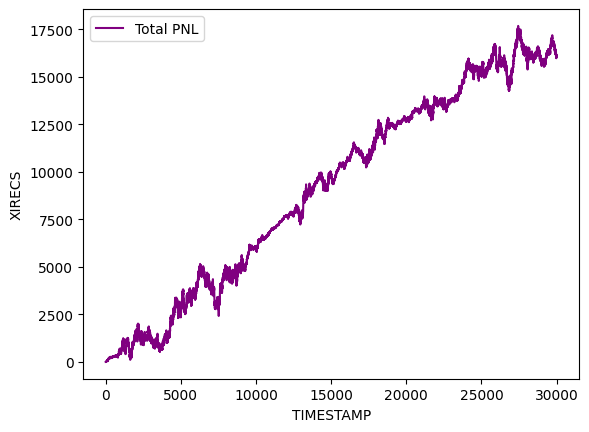

In [453]:
backtesting_result.graph_pnl()